# Getting started

## What does kpnn2 do?

`kpnn2` turns a named `source`/`target` edgelist into a `LayeredSpec`
so you write ordinary PyTorch with `MaskedLinear` and `SkipAdd`.
Attribution methods are yours; `map_node_attributions()` only names
a layer tensor.

The core idea is to describe a model structure as a graph: each row
in an edgelist defines a directed connection from a `source` node to
a `target` node. `kpnn2.parse_layered()` turns this graph into a
`LayeredSpec` of named layers and fixed connectivity masks. You then
write an ordinary PyTorch `nn.Module` with `MaskedLinear`.

Here, "graph" means the architecture, not a GNN. The same edgelist
format can describe a feedforward KPNN whenever the architecture is
named directed edges.

This is useful whenever a sparsely-connected neural architecture is
known before training and can be represented as named edges.

## Domain example: knowledge-primed neural networks

One important use case is a knowledge-primed neural network (KPNN).
In a KPNN, prior knowledge encoded as a graph constrains the
structure of a neural network. Instead of starting from a fully
generic architecture, the model structure is informed by known
relationships between named entities.

This is useful because the hidden nodes of the neural network can be
designed to correspond directly to meaningful domain entities. In a
biological KPNN, for example, hidden nodes may represent
transcription factors, kinases, pathways, or other biological
processes. After training, attribution methods can then assign
importance scores not only to input features, but also to these
hidden nodes. Because the hidden nodes are mapped one-to-one to
named biological entities, node-level attributions can be
interpreted as attributions for those entities. This approach makes
the neural networks interpretable.

The figure below illustrates this idea in a biological setting,
where entities such as genes, transcription factors, kinases,
pathways, and phenotypes can be connected through prior knowledge.

![KPNNs explained](../figures/KPNNs_explained.svg)

**Figure 1.** In a pathway-based KPNN, prior biological knowledge is
encoded directly into the neural network topology. Hidden nodes
represent named biological entities such as receptors, kinases,
transcription factors, or pathways, input nodes for example are
genes, and edges represent curated regulatory or signaling
interactions. This creates a sparsely-connected neural network in
which information flow is constrained by the provided biological
graph, and attribution scores for neural network nodes can be mapped
back to the corresponding biological entities.

Examples of such biologically informed neural networks include
pathway-based models as in
[Fortelny and Bock, 2020](https://doi.org/10.1186/s13059-020-02100-5)
and ontology-based models such as in
[Elmarakeby et al., 2021](https://doi.org/10.1038/s41586-021-03922-4).

This is one domain-specific example of the broader `kpnn2`
abstraction: if a model architecture can be written as named edges,
it can be turned into masked PyTorch layers and interpreted back in
the space of its named features and nodes.

## The kpnn2 workflow

Starting point is a graph that describes the neural network
architecture. In `kpnn2`, this graph is represented as an edge list,
where each row defines a directed connection between named nodes.
`parse_layered()` returns a `LayeredSpec`. Adjacent hops are mask
tensors for `MaskedLinear`. Skips stay out of masks; inject them
with `SkipAdd` in `forward()` (see [Skip edges](../skip-edges/)).

The model is a normal PyTorch `nn.Module`. You choose activations,
dropout, task-specific heads, losses, optimizers, and the training
loop.

After training, run any attribution method you like (this notebook
uses Captum). Then `map_node_attributions()` labels a layer tensor
as an xarray DataArray with the node names from the original
edgelist. `kpnn2` does not import Captum.

This notebook shows a basic `kpnn2` workflow:

1. represent a model architecture as an edgelist
2. parse it into a `LayeredSpec` and write a `MaskedLinear` module
3. align named inputs, train with ordinary PyTorch
4. attribute the trained model back to named features and nodes

The example uses biological names because KPNNs are a natural
application area, but the same workflow applies to other domains
where the architecture can be expressed as a graph.


## Installation

Install `kpnn2` from PyPI with:

```bash
pip install kpnn2
```

The later interpretation cells also need Captum, which is not a
`kpnn2` dependency:

```bash
pip install captum
```

Graphviz is used only to draw the toy graph in this notebook.


## Imports


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from graphviz import Digraph
from IPython.display import display
from matplotlib import pyplot as plt
from torch import nn

import kpnn2 as k2

In [2]:
import random

from matplotlib_inline.backend_inline import (
    set_matplotlib_formats,
)

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

set_matplotlib_formats(
    "svg",
    bbox_inches=None,
)
_FONT_SIZE = 14
_FIG_W = 7.0
_plot_rc = {
    "font.size": _FONT_SIZE,
    "axes.titlesize": _FONT_SIZE,
    "axes.labelsize": _FONT_SIZE,
    "xtick.labelsize": _FONT_SIZE,
    "ytick.labelsize": _FONT_SIZE,
    "legend.fontsize": _FONT_SIZE,
    "legend.title_fontsize": _FONT_SIZE,
    "lines.linewidth": 1.0,
    "font.family": "Liberation Sans",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
    "axes.grid": False,
    "axes.facecolor": "none",
    "figure.facecolor": "none",
    "savefig.facecolor": "none",
    "savefig.edgecolor": "none",
    "svg.fonttype": "none",
}
plt.rcParams.update(_plot_rc)
sns.set_theme(
    style="ticks",
    rc=_plot_rc,
)


def _new_fig(height):
    return plt.figure(figsize=(_FIG_W, height))


def _style_ax(ax):
    ax.tick_params(labelsize=_FONT_SIZE)
    ax.title.set_fontsize(_FONT_SIZE)
    ax.xaxis.label.set_size(_FONT_SIZE)
    ax.yaxis.label.set_size(_FONT_SIZE)
    ax.set_facecolor("none")
    ax.grid(False)

## Step 1: define a prior-knowledge graph

Currently, `kpnn2` expects an edgelist with two required columns,
`source` and `target`. Extra columns are ignored.
`parse_layered()` requires the graph to be a DAG and raises on a
cycle. A graph with feedback loops goes through the other parser,
`parse_adjacency()`, shown in the
[Recurrent example](../recurrent-example/).

Here we define a small feedforward biological graph with two clearly
separated branches:

- a **signal branch**, connected to informative input features
- a **noise branch**, connected to uninformative input features

This makes the later interpretation steps easier to understand:
after training, informative features and their connected hidden
nodes should receive stronger attributions than the uninformative
branch.


In [3]:
edgelist = pd.DataFrame(
    {
        "source": [
            "gene_signal_1",
            "gene_signal_2",
            "gene_signal_3",
            "gene_noise_1",
            "gene_noise_2",
            "gene_noise_3",
            "tf_signal",
            "tf_noise",
            "kinase_signal",
            "kinase_noise",
        ],
        "target": [
            "tf_signal",
            "tf_signal",
            "tf_signal",
            "tf_noise",
            "tf_noise",
            "tf_noise",
            "kinase_signal",
            "kinase_noise",
            "output_1",
            "output_1",
        ],
    }
)

edgelist

,source,target
0,gene_signal_1,tf_signal
1,gene_signal_2,tf_signal
2,gene_signal_3,tf_signal
3,gene_noise_1,tf_noise
4,gene_noise_2,tf_noise
5,gene_noise_3,tf_noise
6,tf_signal,kinase_signal
7,tf_noise,kinase_noise
8,kinase_signal,output_1
9,kinase_noise,output_1


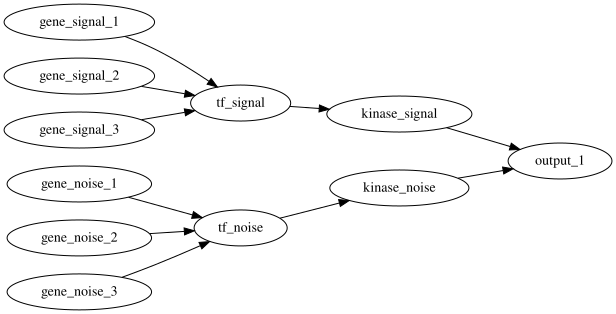

In [4]:
# Visualize the graph

dot = Digraph()
dot.attr(rankdir="LR")

input_nodes = [
    "gene_signal_1",
    "gene_signal_2",
    "gene_signal_3",
    "gene_noise_1",
    "gene_noise_2",
    "gene_noise_3",
]
layer_1_nodes = ["tf_signal", "tf_noise"]
layer_2_nodes = ["kinase_signal", "kinase_noise"]
output_nodes = ["output_1"]

with dot.subgraph() as s:
    s.attr(rank="same")
    for node in input_nodes:
        s.node(node, node)

with dot.subgraph() as s:
    s.attr(rank="same")
    for node in layer_1_nodes:
        s.node(node, node)

with dot.subgraph() as s:
    s.attr(rank="same")
    for node in layer_2_nodes:
        s.node(node, node)

with dot.subgraph() as s:
    s.attr(rank="same")
    for node in output_nodes:
        s.node(node, node)

for _, row in edgelist.iterrows():
    dot.edge(row["source"], row["target"])

dot

## Step 2: parse the edgelist and write a module

`parse_layered(...)` returns a `LayeredSpec`: named nodes by layer,
adjacent-hop mask tensors, and skip-edge metadata. It does not
return an `nn.Module`.

You build the network with `MaskedLinear(spec.masks[i])` for each
adjacent hop. Activations and the task head are ordinary PyTorch.


In [5]:
torch.manual_seed(42)
spec = k2.parse_layered(edgelist)
spec.input_nodes, spec.hidden_nodes, spec.output_nodes

(('gene_noise_1',
  'gene_noise_2',
  'gene_noise_3',
  'gene_signal_1',
  'gene_signal_2',
  'gene_signal_3'),
 ('kinase_noise', 'kinase_signal', 'tf_noise', 'tf_signal'),
 ('output_1',))

### Inspect the LayeredSpec

`spec.layer_nodes[i]` is the names at depth `i`. `spec.masks[i]` is
the fixed connectivity from layer `i` to layer `i + 1`. This graph
has no skip edges (`spec.skips` is empty): every original edge has
depth gap 1. When an edgelist jumps a layer, construct `SkipAdd`
once and call it after every hop, before ReLU or BatchNorm; see
[Skip edges](../skip-edges/).


In [6]:
spec.layer_nodes

(('gene_noise_1',
  'gene_noise_2',
  'gene_noise_3',
  'gene_signal_1',
  'gene_signal_2',
  'gene_signal_3'),
 ('tf_noise', 'tf_signal'),
 ('kinase_noise', 'kinase_signal'),
 ('output_1',))

In [7]:
[tuple(mask.shape) for mask in spec.masks]

[(2, 6), (2, 2), (1, 2)]

In [8]:
spec.skips

()

The model is a small `nn.Module`. ReLU is applied after every hop
except the last graph hop. We add a one-dimensional linear head
that outputs a single logit. We do not add a ReLU after `output_1`:
applying ReLU to this scalar bottleneck can suppress gradients if
the output is negative.

ReLU can also zero a whole branch if that branch starts with
negative pre-activations. Both branches of this toy graph should
be able to learn, so we initialize each `MaskedLinear` bias to
`1.0`. Without that, the swap control later can fail even when
the labels sit on the noise-branch genes.


In [9]:
class KPNN(nn.Module):
    def __init__(self, spec: k2.LayeredSpec):
        super().__init__()
        self.spec = spec
        layers = []
        for mask in spec.masks:
            layers.append(k2.MaskedLinear(mask))
        self.layers = nn.ModuleList(layers)
        self.head = nn.Linear(1, 1)
        for layer in self.layers:
            if layer.bias is not None:
                nn.init.constant_(
                    layer.bias,
                    1.0,
                )

    def forward(self, x):
        hidden = x
        last_hop = len(self.layers) - 1
        for hop, layer in enumerate(self.layers):
            hidden = layer(hidden)
            if hop < last_hop:
                hidden = F.relu(hidden)
        return self.head(hidden)


model = KPNN(spec)
model

KPNN(
  (layers): ModuleList(
    (0): ParametrizedMaskedLinear(
      in_features=6, out_features=2, bias=True
      (parametrizations): ModuleDict(
        (weight): ParametrizationList(
          (0): _MaskParametrization()
        )
      )
    )
    (1): ParametrizedMaskedLinear(
      in_features=2, out_features=2, bias=True
      (parametrizations): ModuleDict(
        (weight): ParametrizationList(
          (0): _MaskParametrization()
        )
      )
    )
    (2): ParametrizedMaskedLinear(
      in_features=2, out_features=1, bias=True
      (parametrizations): ModuleDict(
        (weight): ParametrizationList(
          (0): _MaskParametrization()
        )
      )
    )
  )
  (head): Linear(in_features=1, out_features=1, bias=True)
)

The printed name is `ParametrizedMaskedLinear`, not
`MaskedLinear`. That is PyTorch's own wording for a layer whose
weight is a function of a stored parameter: `MaskedLinear`
registers the connectivity mask with
`torch.nn.utils.parametrize`, so `layer.weight` is the effective
masked weight and the trainable tensor sits at
`layer.parametrizations.weight.original`. Optimizers, weight
decay, and `state_dict` see it under the usual `weight` name,
and `isinstance(layer, k2.MaskedLinear)` is still `True`.


## Step 3: simulate data and align it to the model

The model expects input features in the exact order stored in
`spec.input_nodes`. In practice, input data often comes from a
DataFrame where features are named but not necessarily ordered like
the model input layer.

`align_inputs()` uses the `LayeredSpec` to reorder named input
features into the tensor layout expected by the model. This
prevents silent feature-order mismatches between the data and the
architecture.

For this tutorial, we first simulate a small binary classification
dataset. The `gene_signal_*` features carry class information,
while the `gene_noise_*` features are uninformative. We achieve
this by sampling every feature from a normal distribution: the
`gene_signal_*` features use a different mean in each class, so
there is a real class difference the model can exploit, while the
`gene_noise_*` features use the same mean in both classes, so any
apparent difference between the classes is only random sampling
variation.


In [10]:
# Simulate the training and test data
rng = np.random.default_rng(42)

informative_features = [
    "gene_signal_1",
    "gene_signal_2",
    "gene_signal_3",
]

noise_features = [
    "gene_noise_1",
    "gene_noise_2",
    "gene_noise_3",
]

all_features = informative_features + noise_features

n_train_per_class = 100
n_test_per_class = 50


def simulate_binary_classification_data(n_per_class, rng):
    x0_signal = rng.normal(
        loc=0.0,
        scale=1.0,
        size=(n_per_class, len(informative_features)),
    )
    x1_signal = rng.normal(
        loc=2.0,
        scale=1.0,
        size=(n_per_class, len(informative_features)),
    )
    x0_noise = rng.normal(
        loc=0.0,
        scale=1.0,
        size=(n_per_class, len(noise_features)),
    )
    x1_noise = rng.normal(
        loc=0.0,
        scale=1.0,
        size=(n_per_class, len(noise_features)),
    )
    x0 = np.concatenate([x0_signal, x0_noise], axis=1)
    x1 = np.concatenate([x1_signal, x1_noise], axis=1)
    x = np.concatenate([x0, x1], axis=0)
    y = np.concatenate(
        [
            np.zeros(n_per_class, dtype=int),
            np.ones(n_per_class, dtype=int),
        ]
    )
    permutation = rng.permutation(len(y))
    x = x[permutation]
    y = y[permutation]
    x_df = pd.DataFrame(x, columns=all_features)
    y_series = pd.Series(y, name="label")
    return x_df, y_series


x_train_df, y_train = simulate_binary_classification_data(
    n_per_class=n_train_per_class,
    rng=rng,
)
x_test_df, y_test = simulate_binary_classification_data(
    n_per_class=n_test_per_class,
    rng=rng,
)

display(x_train_df.head())
display(y_train.head())
display(x_test_df.head())
display(y_test.head())

,gene_signal_1,gene_signal_2,gene_signal_3,gene_noise_1,gene_noise_2,gene_noise_3
0,-0.695943,-0.223859,0.242497,-1.139429,-0.481241,1.437777
1,3.068472,2.232878,2.234401,-0.712102,1.370541,-0.484030
2,-0.471525,0.263717,0.052467,0.288917,1.244947,-0.431339
3,0.941464,1.874991,3.481456,-0.109727,-0.035611,-1.364742
4,-0.926576,-0.389810,-1.376686,-1.119536,0.447814,0.058274


0    0
1    1
2    0
3    1
4    0
Name: label, dtype: int64

,gene_signal_1,gene_signal_2,gene_signal_3,gene_noise_1,gene_noise_2,gene_noise_3
0,-0.306566,-0.593220,-0.325545,-0.491747,0.892856,-0.774510
1,1.687645,3.358121,2.508079,0.619105,-1.160912,0.032370
2,-0.379687,0.376948,-1.126988,1.191390,-0.696212,0.223967
3,0.466178,-0.376212,-0.507105,-1.567177,0.388474,-1.759816
4,1.239810,2.577403,2.046557,-1.466186,-1.093737,1.026906


0    0
1    1
2    0
3    0
4    1
Name: label, dtype: int64

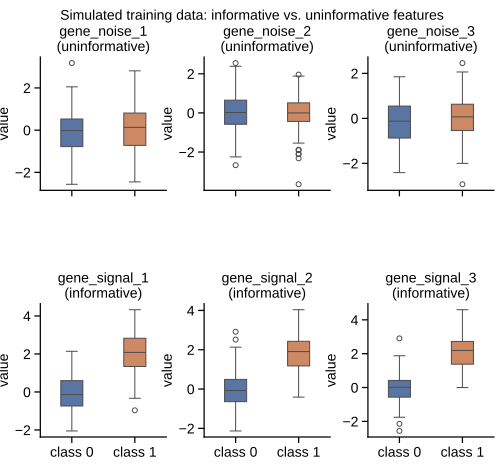

In [11]:
# Visualize the simulated training data

plot_df = x_train_df.copy()
plot_df["label"] = y_train.values
plot_df["class"] = plot_df["label"].map({0: "class 0", 1: "class 1"})

long_df = plot_df.melt(
    id_vars=["label", "class"],
    value_vars=spec.input_nodes,
    var_name="feature",
    value_name="value",
)

feature_type_map = {
    "gene_signal_1": "informative",
    "gene_signal_2": "informative",
    "gene_signal_3": "informative",
    "gene_noise_1": "uninformative",
    "gene_noise_2": "uninformative",
    "gene_noise_3": "uninformative",
}
long_df["feature_type"] = long_df["feature"].map(feature_type_map)

n_cols = 3
g = sns.catplot(
    data=long_df,
    x="class",
    y="value",
    col="feature",
    col_wrap=n_cols,
    hue="class",
    kind="box",
    width=0.35,
    sharey=False,
    height=3.3,
    aspect=1.0,
    legend=False,
)
g.fig.set_size_inches(_FIG_W, g.fig.get_figheight())
g.fig.suptitle(
    "Simulated training data: informative vs. uninformative features",
    fontsize=_FONT_SIZE,
    y=0.98,
)
g.fig.subplots_adjust(
    top=0.88,
    bottom=0.08,
    left=0.08,
    right=0.98,
    hspace=0.85,
    wspace=0.3,
)
for ax, feature in zip(g.axes.flat, spec.input_nodes):
    feature_type = feature_type_map[feature]
    ax.set_title(f"{feature}\n({feature_type})")
    ax.set_xlabel("")
    ax.set_ylabel("value")
    _style_ax(ax)
g.fig.patch.set_facecolor("none")
plt.show()

In [12]:
x_train = k2.align_inputs(
    x_train_df,
    spec,
)
x_test = k2.align_inputs(
    x_test_df,
    spec,
)
x_train.shape, x_test.shape

(torch.Size([200, 6]), torch.Size([100, 6]))

To verify that alignment is based on feature names, we deliberately
reverse the DataFrame columns and align the shuffled DataFrame
again. The result is identical to the original aligned tensor.


In [13]:
# Alignment is name-based, not position-based.
# Even if the DataFrame columns are shuffled, the aligned tensor
# is unchanged.

shuffled_columns = list(reversed(spec.input_nodes))
x_train_df_shuffled = x_train_df[shuffled_columns]
x_train_from_shuffled = k2.align_inputs(
    x_train_df_shuffled,
    spec,
)
torch.allclose(x_train, x_train_from_shuffled)

True

<div class="admonition warning">
<p class="admonition-title">Keep the LayeredSpec input order</p>
<p>PyTorch never sees feature names. Column <code>i</code> is
whatever name is in <code>spec.input_nodes[i]</code>. Keep this
<code>model</code> with this <code>spec</code>, and build every
train/val/test tensor with
<code>align_inputs(..., spec)</code>.</p>
<p>Do not pass <code>df.values</code> (or any hand-built array)
into the model: if the width is right, training still runs and the
features are silently wired to the wrong nodes. Extra columns and
shuffled DataFrame order are fine; renaming required columns is
not.</p>
</div>


## Step 4: train the model in PyTorch

The `KPNN` module is still a normal PyTorch module. This means it
can be trained with ordinary PyTorch components such as loss
functions, optimizers, and training loops.

Below is a minimal training loop that shows how the masked
structural core and the added head fit directly into a standard
PyTorch workflow.


Loss before first update: 0.7145
Loss after final update:  0.1288


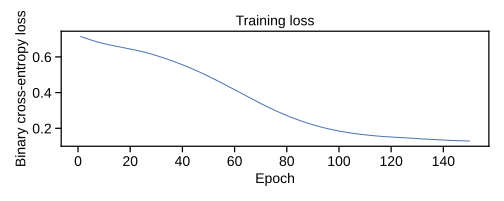

In [14]:
# Train the model with the simulated data

y_train_tensor = torch.tensor(
    y_train.values.reshape(-1, 1),
    dtype=torch.float32,
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-2,
)
loss_fn = nn.BCEWithLogitsLoss()

n_epochs = 150
loss_history = []
model.train()

for epoch in range(n_epochs):
    optimizer.zero_grad()
    logits = model(x_train)
    loss = loss_fn(logits, y_train_tensor)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

print("Loss before first update:", round(loss_history[0], 4))
print("Loss after final update: ", round(loss_history[-1], 4))

_new_fig(2.8)
plt.plot(
    range(1, n_epochs + 1),
    loss_history,
    linewidth=1,
)
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Training loss")
plt.tight_layout()
plt.show()

## Step 5: feature-level interpretation

Feature-level interpretation maps attributions back to the input
features.

For this example, we use Captum `IntegratedGradients` on the
trained module. `kpnn2` does not wrap Captum. The result is a
tensor of shape `(n_test, n_input_nodes)`. Columns follow
`spec.input_nodes`, the same order as `align_inputs`.

Those values are signed Captum scores. The `mean_abs_attribution`
column below is computed with `.abs()` for ranking.

Because the dataset was simulated, we know which features truly
separate the two classes: the `gene_signal_*` features were
generated with different class means, whereas the `gene_noise_*`
features were not.

This gives us a useful sanity check for interpretation. The
recovered feature attributions do not need to match the simulated
class mean differences exactly, but the informative features should
generally receive larger attribution magnitudes than the
uninformative ones.


In [15]:
from captum.attr import IntegratedGradients

model.eval()
ig = IntegratedGradients(model)
feature_tensor = ig.attribute(
    x_test,
    target=0,
)
feature_attr = pd.DataFrame(
    feature_tensor.detach().cpu().numpy(),
    columns=spec.input_nodes,
)
feature_attr.head()

,gene_noise_1,gene_noise_2,gene_noise_3,gene_signal_1,gene_signal_2,gene_signal_3
0,0.015065,0.091274,0.105600,-0.000000,-0.000000,-0.000000
1,-0.015479,-0.096852,-0.003602,1.761106,1.880482,3.695487
2,-0.030644,-0.059754,-0.025638,-0.000000,0.000000,-0.000000
3,0.048012,0.039713,0.239940,0.000000,-0.000000,-0.000000
4,0.025247,-0.062843,-0.078695,1.674302,1.867795,3.902372


In [16]:
# Summarize feature attributions and compare them to the simulated
# signal

class_mean_diff = (
    x_test_df.loc[y_test == 1].mean() - x_test_df.loc[y_test == 0].mean()
)

feature_summary = pd.DataFrame(
    {
        "feature": spec.input_nodes,
        "abs_class_mean_difference": (
            class_mean_diff.abs().reindex(spec.input_nodes).values
        ),
        "mean_abs_attribution": (
            feature_attr.abs().mean(axis=0).reindex(spec.input_nodes).values
        ),
        "mean_signed_attribution": (
            feature_attr.mean(axis=0).reindex(spec.input_nodes).values
        ),
    }
)
feature_summary["feature_type"] = feature_summary["feature"].map(
    feature_type_map
)
feature_summary

,feature,abs_class_mean_difference,mean_abs_attribution,mean_signed_attribution,feature_type
0,gene_noise_1,0.223047,0.023822,0.007829,uninformative
1,gene_noise_2,0.251055,0.068964,-0.000599,uninformative
2,gene_noise_3,0.089079,0.091703,0.027224,uninformative
3,gene_signal_1,2.086208,1.405798,1.299942,informative
4,gene_signal_2,1.477629,0.724375,0.639321,informative
5,gene_signal_3,1.617368,1.829459,1.812096,informative


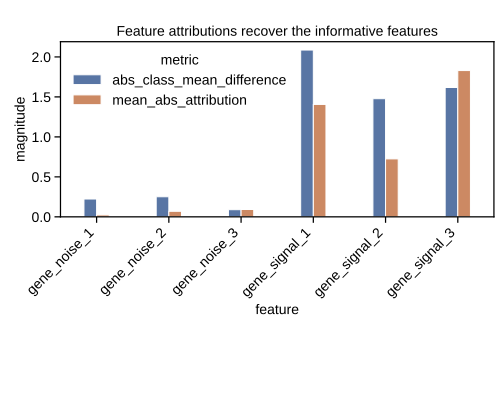

In [17]:
# Plot recovered attributions against the true simulated signal

plot_df = feature_summary.melt(
    id_vars=["feature", "feature_type"],
    value_vars=[
        "abs_class_mean_difference",
        "mean_abs_attribution",
    ],
    var_name="metric",
    value_name="value",
)

_new_fig(5.8)
sns.barplot(
    data=plot_df,
    x="feature",
    y="value",
    hue="metric",
    width=0.35,
)
sns.move_legend(
    plt.gca(),
    "upper left",
    frameon=False,
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("magnitude")
plt.title("Feature attributions recover the informative features")
plt.subplots_adjust(
    left=0.12,
    right=0.98,
    bottom=0.48,
    top=0.9,
)
plt.show()

## Step 6: node-level interpretation

Node-level interpretation maps attribution scores back to the
internal nodes of the graph.

For this example, we use Captum `LayerConductance` on each
`MaskedLinear` hop. `map_node_attributions()` then labels the
`(batch, n_units)` tensor as an xarray DataArray with
`spec.layer_nodes[layer]` on the `node` axis.

`MaskedLinear` hop `i` produces the activations at layer `i + 1`,
so we pass `layer=i + 1`. Input features are not included; use the
feature table from Step 5 for inputs. The mapper itself is walked
through in [Mapping attributions](../map-node-attributions/).

Those values are signed. The plots below use `.abs()` so we can
compare overall importance when signs would otherwise cancel.

This is often the most interesting interpretation level, because it
helps show which hidden biological entities in the network carry
signal for the task.

Because this dataset was simulated with informative and
uninformative feature groups, we expect nodes on the informative
branch of the graph to tend to show larger attribution magnitudes
than nodes on branches driven mainly by noise.


In [18]:
from captum.attr import LayerConductance

node_attr_by_layer = {}
for hop, layer_module in enumerate(model.layers):
    conductor = LayerConductance(
        model,
        layer_module,
    )
    attributions = conductor.attribute(
        x_test,
        target=0,
    )
    layer_index = hop + 1
    node_attr_by_layer[layer_index] = k2.map_node_attributions(
        attributions=attributions,
        spec=spec,
        layer=layer_index,
    )

for layer_index, da in node_attr_by_layer.items():
    print("layer", layer_index, spec.layer_nodes[layer_index])
    display(da.to_pandas().head())

layer 1 ('tf_noise', 'tf_signal')


node,tf_noise,tf_signal
observation,,
0,0.211708,0.000000
1,-0.118422,7.524203
2,-0.118261,0.000000
3,0.327308,0.000000
4,-0.115929,7.467299


layer 2 ('kinase_noise', 'kinase_signal')


node,kinase_noise,kinase_signal
observation,,
0,0.211708,0.000000
1,-0.115523,7.674946
2,-0.115525,0.000000
3,0.327308,0.000000
4,-0.115488,7.567295


layer 3 ('output_1',)


node,output_1
observation,
0,0.211708
1,7.354515
2,-0.115525
3,0.327308
4,7.354550


To make the node-level results easier to interpret, we now summarize
the attributions across the test set.

For each node, we compute:

- the mean attribution
- the mean absolute attribution

The mean absolute attribution is often especially useful, because
it reflects overall importance even when positive and negative
values cancel out on average. That `.abs()` step is a display
choice; `map_node_attributions()` keeps the signed scores
as xarray.


In [19]:
node_summary_frames = []
for layer_index, da in node_attr_by_layer.items():
    layer_df = da.to_pandas()
    layer_summary = pd.DataFrame(
        {
            "layer": layer_index,
            "node": layer_df.columns,
            "mean_attribution": layer_df.mean(axis=0).values,
            "mean_abs_attribution": layer_df.abs().mean(axis=0).values,
        }
    )
    node_summary_frames.append(layer_summary)

node_summary = (
    pd.concat(node_summary_frames, ignore_index=True)
    .sort_values(
        ["layer", "mean_abs_attribution"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)
node_summary

,layer,node,mean_attribution,mean_abs_attribution
0,1,tf_signal,3.744823,3.744823
1,1,tf_noise,0.033555,0.125037
2,2,kinase_signal,3.795717,3.795717
3,2,kinase_noise,0.034420,0.124173
4,3,output_1,3.787767,3.811863


The following plot shows the mean absolute attribution for each
internal node across the test set. Magnitude is used here only so
the ranking is easy to read.


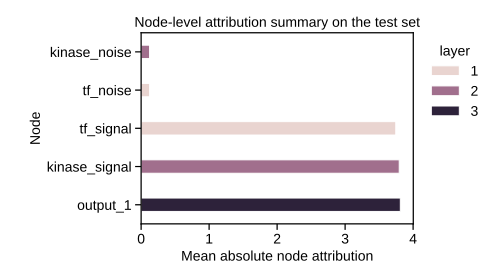

In [20]:
plot_df = node_summary.sort_values(
    "mean_abs_attribution",
    ascending=True,
)

_new_fig(3.8)
sns.barplot(
    data=plot_df,
    x="mean_abs_attribution",
    y="node",
    hue="layer",
    dodge=False,
    width=0.35,
)
sns.move_legend(
    plt.gca(),
    "upper left",
    bbox_to_anchor=(1.02, 1.0),
    frameon=False,
)
plt.xlabel("Mean absolute node attribution")
plt.ylabel("Node")
plt.title("Node-level attribution summary on the test set")
plt.subplots_adjust(
    left=0.28,
    right=0.82,
    bottom=0.18,
    top=0.88,
)
plt.show()

## Control: swap which branch is informative

The main example already pairs a positive and negative control in
one experiment: the signal branch lights up and the noise branch
stays low. The architecture is symmetric, so that contrast is
fairly strong on its own.

One remaining check is a **swap control**: put class signal on the
former noise genes instead. If attribution tracks the data rather
than branch identity, importance should move to `tf_noise` /
`kinase_noise`, while the former signal branch should drop.

This section is intentionally short: same graph, swapped
informative features, retrain, and compare node importance.


,node,main_example,swap_control,branch
3,tf_noise,0.125037,3.252807,noise branch
0,kinase_noise,0.124173,3.209374,noise branch
2,output_1,3.811863,3.166344,output
4,tf_signal,3.744823,0.138441,signal branch
1,kinase_signal,3.795717,0.137547,signal branch


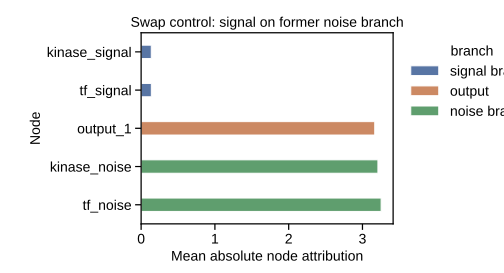

In [21]:
# Control: class signal on the former noise genes.
torch.manual_seed(42)
rng_swap = np.random.default_rng(42)

swap_informative = [
    "gene_noise_1",
    "gene_noise_2",
    "gene_noise_3",
]
swap_uninformative = [
    "gene_signal_1",
    "gene_signal_2",
    "gene_signal_3",
]
swap_features = swap_informative + swap_uninformative


def simulate_swap(n_per_class, rng):
    n_inf = len(swap_informative)
    n_noise = len(swap_uninformative)
    x0 = np.concatenate(
        [
            rng.normal(0.0, 1.0, size=(n_per_class, n_inf)),
            rng.normal(0.0, 1.0, size=(n_per_class, n_noise)),
        ],
        axis=1,
    )
    x1 = np.concatenate(
        [
            rng.normal(2.0, 1.0, size=(n_per_class, n_inf)),
            rng.normal(0.0, 1.0, size=(n_per_class, n_noise)),
        ],
        axis=1,
    )
    x = np.concatenate([x0, x1], axis=0)
    y = np.concatenate(
        [
            np.zeros(n_per_class, dtype=int),
            np.ones(n_per_class, dtype=int),
        ]
    )
    perm = rng.permutation(len(y))
    return (
        pd.DataFrame(x[perm], columns=swap_features),
        pd.Series(y[perm], name="label"),
    )


x_swap_train_df, y_swap_train = simulate_swap(100, rng_swap)
x_swap_test_df, y_swap_test = simulate_swap(50, rng_swap)

swap_spec = k2.parse_layered(edgelist)
swap_model = KPNN(swap_spec)
x_swap_train = k2.align_inputs(
    x_swap_train_df,
    swap_spec,
)
y_swap_tensor = torch.tensor(
    y_swap_train.values.reshape(-1, 1),
    dtype=torch.float32,
)

optimizer = torch.optim.Adam(
    swap_model.parameters(),
    lr=1e-2,
)
loss_fn = nn.BCEWithLogitsLoss()
swap_model.train()
for _ in range(150):
    optimizer.zero_grad()
    loss = loss_fn(swap_model(x_swap_train), y_swap_tensor)
    loss.backward()
    optimizer.step()

swap_model.eval()
x_swap_test = k2.align_inputs(
    x_swap_test_df,
    swap_spec,
)
swap_frames = []
for hop, layer_module in enumerate(swap_model.layers):
    conductor = LayerConductance(
        swap_model,
        layer_module,
    )
    attributions = conductor.attribute(
        x_swap_test,
        target=0,
    )
    layer_df = k2.map_node_attributions(
        attributions=attributions,
        spec=swap_spec,
        layer=hop + 1,
    ).to_pandas()
    swap_frames.append(layer_df)

swap_node_attr = pd.concat(swap_frames, axis=1)
swap_summary = (
    swap_node_attr.abs()
    .mean(axis=0)
    .rename("mean_abs_attribution")
    .reset_index()
    .rename(columns={"index": "node"})
)
branch_map = {
    "tf_signal": "signal branch",
    "kinase_signal": "signal branch",
    "tf_noise": "noise branch",
    "kinase_noise": "noise branch",
    "output_1": "output",
}
swap_summary["branch"] = swap_summary["node"].map(branch_map)

main_internal = (
    node_summary.loc[
        node_summary["node"].isin(branch_map),
        ["node", "mean_abs_attribution"],
    ]
    .groupby("node", as_index=False)["mean_abs_attribution"]
    .max()
    .rename(columns={"mean_abs_attribution": "main_example"})
)
compare = main_internal.merge(
    swap_summary[["node", "mean_abs_attribution", "branch"]],
    on="node",
    how="outer",
).rename(columns={"mean_abs_attribution": "swap_control"})
compare = compare.sort_values("swap_control", ascending=False)
display(compare)

_new_fig(3.8)
sns.barplot(
    data=swap_summary.sort_values(
        "mean_abs_attribution",
        ascending=True,
    ),
    x="mean_abs_attribution",
    y="node",
    hue="branch",
    dodge=False,
    width=0.35,
)
sns.move_legend(
    plt.gca(),
    "upper left",
    bbox_to_anchor=(1.02, 1.0),
    frameon=False,
)
plt.xlabel("Mean absolute node attribution")
plt.ylabel("Node")
plt.title("Swap control: signal on former noise branch")
plt.subplots_adjust(
    left=0.28,
    right=0.78,
    bottom=0.18,
    top=0.88,
)
plt.show()

If the swap worked, mean absolute attribution should concentrate on
the noise-branch nodes (`tf_noise`, `kinase_noise`) rather than the
signal-branch nodes (`tf_signal`, `kinase_signal`). That confirms
the quiet noise branch in the main example reflected uninformative
inputs, not a structural preference for the left-hand pathway.
